In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('../raw_data/snotel_monthly_swe_prediction.csv')
df['month_end'] = pd.to_datetime(df['month_end'])
df = df[df['month_end'].dt.year >= 2005].copy()
df = df.sort_values(['station_triplet', 'month_end']).copy()
df['_months_of_station_history'] = df.groupby('station_triplet').cumcount()
df = df[df['_months_of_station_history'] >= 12].drop(columns='_months_of_station_history').copy()


def add_historical_target_swe_median(df):
    df = df.copy()
    df['target_month_end'] = pd.to_datetime(df['target_month_end'])
    df['_target_month'] = df['target_month_end'].dt.month
    df['_target_day'] = df['target_month_end'].dt.day
    df['_target_year'] = df['target_month_end'].dt.year

    yearly_target_swe = (
        df.dropna(subset=['target_month_end', 'target_swe_next_month'])
        .groupby(
            ['station_triplet', '_target_month', '_target_day', '_target_year'],
            as_index=False,
        )['target_swe_next_month']
        .median()
        .sort_values(['station_triplet', '_target_month', '_target_day', '_target_year'])
    )

    yearly_target_swe['historical_target_swe_median'] = (
        yearly_target_swe
        .groupby(['station_triplet', '_target_month', '_target_day'])['target_swe_next_month']
        .transform(lambda s: s.shift().expanding(min_periods=1).median())
    )

    df = df.merge(
        yearly_target_swe[
            [
                'station_triplet',
                '_target_month',
                '_target_day',
                '_target_year',
                'historical_target_swe_median',
            ]
        ],
        on=['station_triplet', '_target_month', '_target_day', '_target_year'],
        how='left',
    )

    return df.drop(columns=['_target_month', '_target_day', '_target_year'])


df = add_historical_target_swe_median(df)
df = df[df['target_month_end'].dt.month.isin([11, 12, 1, 2, 3, 4, 5])].copy()
df = df.dropna(subset=['historical_target_swe_median']).copy()
df = df[df.groupby('station_triplet')['month_end'].transform('size') >= 12].copy()

In [29]:
df

,station_triplet,month_end,current_swe,WTEQ_mean,WTEQ_min,WTEQ_max,current_snow_depth,SNWD_mean,SNWD_min,SNWD_max,...,name,stateCode,countyName,huc,elevation,latitude,longitude,beginDate,endDate,historical_target_swe_median
12,1000:OR:SNTL,2007-01-31,23.5,23.012903,18.8,23.9,63.0,66.806452,58.0,74.0,...,Annie Springs,OR,Klamath,180102030101,6020.0,42.87007,-122.16518,2000-09-01 00:00,2100-01-01 00:00,52.60
13,1000:OR:SNTL,2007-02-28,33.8,26.707143,23.2,33.8,115.0,77.785714,61.0,115.0,...,Annie Springs,OR,Klamath,180102030101,6020.0,42.87007,-122.16518,2000-09-01 00:00,2100-01-01 00:00,63.10
14,1000:OR:SNTL,2007-03-31,36.6,35.967742,34.3,36.8,78.0,89.774194,78.0,115.0,...,Annie Springs,OR,Klamath,180102030101,6020.0,42.87007,-122.16518,2000-09-01 00:00,2100-01-01 00:00,68.00
15,1000:OR:SNTL,2007-04-30,35.2,36.650000,34.5,38.7,69.0,77.966667,69.0,89.0,...,Annie Springs,OR,Klamath,180102030101,6020.0,42.87007,-122.16518,2000-09-01 00:00,2100-01-01 00:00,43.40
21,1000:OR:SNTL,2007-10-31,0.0,0.145161,0.0,0.8,0.0,1.258065,0.0,8.0,...,Annie Springs,OR,Klamath,180102030101,6020.0,42.87007,-122.16518,2000-09-01 00:00,2100-01-01 00:00,8.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189027,999:WA:SNTL,2025-02-28,32.0,28.464286,25.6,32.0,78.0,77.892857,72.0,87.0,...,Marten Ridge,WA,Whatcom,171100051004,3520.0,48.76292,-121.69823,2006-07-01 00:00,2100-01-01 00:00,61.40
189028,999:WA:SNTL,2025-03-31,43.2,39.583871,32.0,48.9,99.0,100.000000,74.0,130.0,...,Marten Ridge,WA,Whatcom,171100051004,3520.0,48.76292,-121.69823,2006-07-01 00:00,2100-01-01 00:00,59.00
189029,999:WA:SNTL,2025-04-30,41.1,44.503333,41.1,46.2,82.0,93.566667,82.0,103.0,...,Marten Ridge,WA,Whatcom,171100051004,3520.0,48.76292,-121.69823,2006-07-01 00:00,2100-01-01 00:00,32.50
189035,999:WA:SNTL,2025-10-31,1.0,0.312903,0.0,1.6,0.0,1.096774,0.0,8.0,...,Marten Ridge,WA,Whatcom,171100051004,3520.0,48.76292,-121.69823,2006-07-01 00:00,2100-01-01 00:00,6.80


## 2. Target Variable Distribution

The prediction target is `target_swe_next_month`, which represents the snow water equivalent at the end of the following month. Understanding its distribution is important because SWE is often highly right-skewed: many station-months may have little or no snow, while high-elevation winter/spring months can have very large SWE values.

count    102976.000000
mean          9.706134
std          11.180947
min           0.000000
25%           1.600000
50%           6.500000
75%          13.600000
max         124.000000
Name: target_swe_next_month, dtype: float64


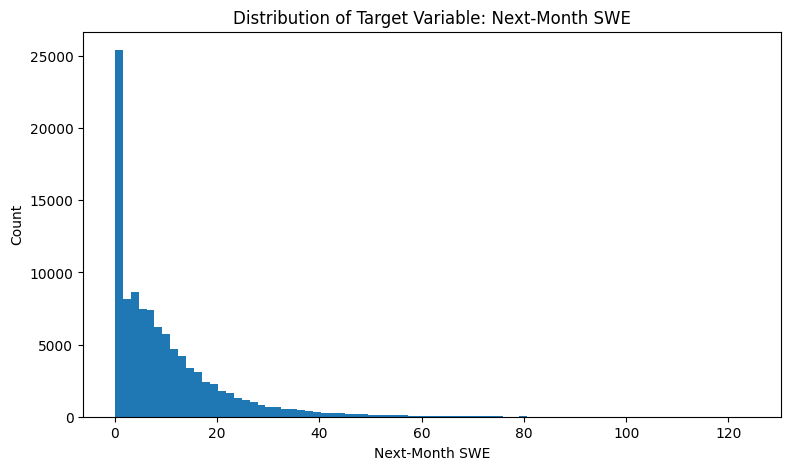

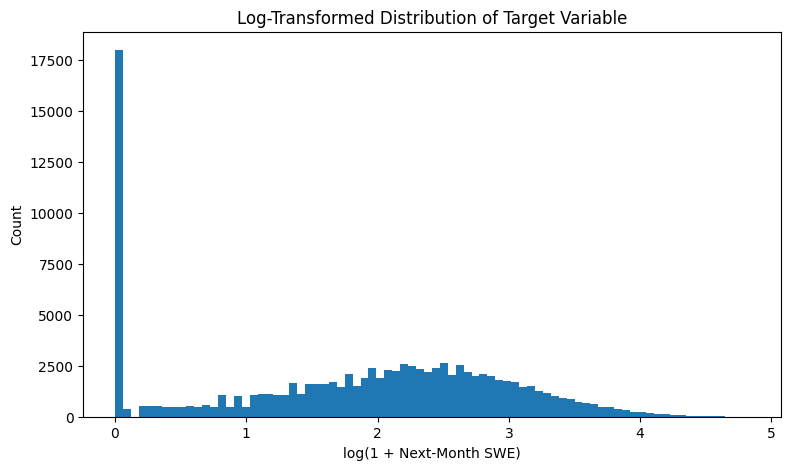

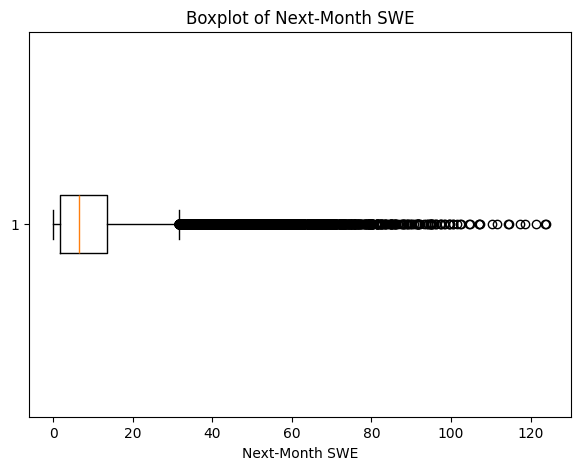

In [30]:
target = "target_swe_next_month"

print(df[target].describe())

plt.figure(figsize=(9, 5))
plt.hist(df[target].dropna(), bins=80)
plt.xlabel("Next-Month SWE")
plt.ylabel("Count")
plt.title("Distribution of Target Variable: Next-Month SWE")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df[target].dropna()), bins=80)
plt.xlabel("log(1 + Next-Month SWE)")
plt.ylabel("Count")
plt.title("Log-Transformed Distribution of Target Variable")
plt.show()

plt.figure(figsize=(7, 5))
plt.boxplot(df[target].dropna(), vert=False)
plt.xlabel("Next-Month SWE")
plt.title("Boxplot of Next-Month SWE")
plt.show()

## 3. Zero-Snow and Low-Snow Analysis

Because many SNOTEL stations may report zero SWE during summer or low-snow periods, it is useful to separately examine how often the target is zero or near zero. This helps determine whether the regression task includes many trivial zero-snow predictions and whether seasonality strongly dominates the target.

Percent of rows with target SWE = 0: 17.46%
Percent of rows with target SWE <= 1 inch: 22.24%


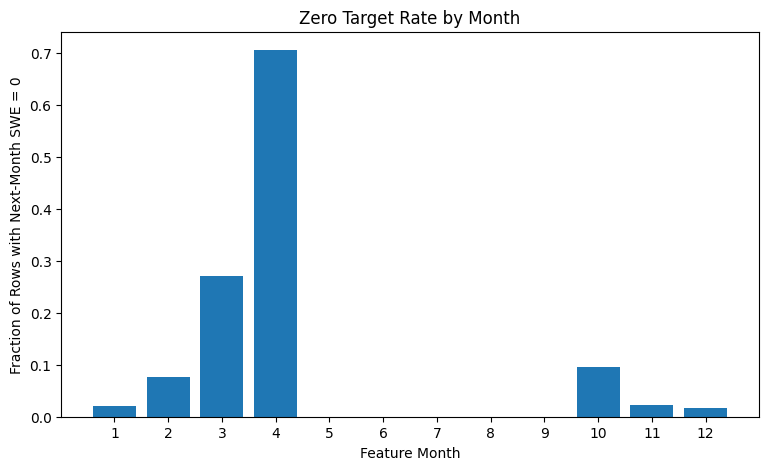

In [31]:
zero_target_rate = (df[target] == 0).mean()
low_target_rate = (df[target] <= 1).mean()

print(f"Percent of rows with target SWE = 0: {zero_target_rate:.2%}")
print(f"Percent of rows with target SWE <= 1 inch: {low_target_rate:.2%}")

zero_by_month = (
    df.assign(target_zero=(df[target] == 0).astype(int))
      .groupby("month")["target_zero"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))
plt.bar(zero_by_month["month"], zero_by_month["target_zero"])
plt.xlabel("Feature Month")
plt.ylabel("Fraction of Rows with Next-Month SWE = 0")
plt.title("Zero Target Rate by Month")
plt.xticks(range(1, 13))
plt.show()

## 4. Missing Data Analysis

Missing data is especially important in environmental datasets because stations may have incomplete records, sensor outages, or missing values for specific weather variables. This section examines missingness by column, station, year, and month.

In [32]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["column", "missing_percent"]
missing

,column,missing_percent
0,SNWD_min,2.094663
1,SNWD_max,2.094663
2,current_snow_depth,2.094663
3,SNWD_mean,2.094663
4,snow_depth_lag_1,2.061645
5,TMAX_mean,0.881759
6,TMAX_max,0.881759
7,TMIN_min,0.813782
8,TMIN_mean,0.813782
9,TAVG_std,0.541874


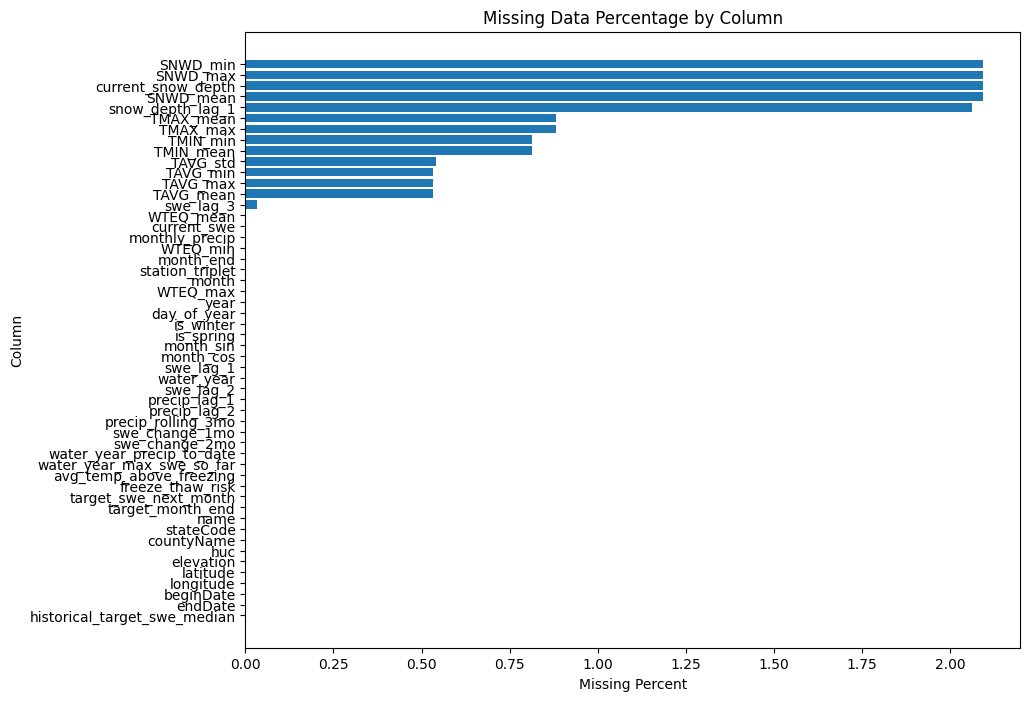

In [33]:
plt.figure(figsize=(10, 8))
plt.barh(missing["column"], missing["missing_percent"])
plt.xlabel("Missing Percent")
plt.ylabel("Column")
plt.title("Missing Data Percentage by Column")
plt.gca().invert_yaxis()
plt.show()

,station_triplet,avg_missing_percent
145,1174:AK:SNTL,9.803922
2,1002:AK:SNTL,9.803922
223,305:CO:SNTL,9.803922
63,1086:AK:SNTL,9.803922
214,1319:WA:SNTL,6.334842
195,1270:AK:SNTL,6.049228
402,492:ID:SNTL,5.463254
603,704:ID:SNTL,5.463254
356,443:NV:SNTL,5.029187
640,741:ID:SNTL,4.939380


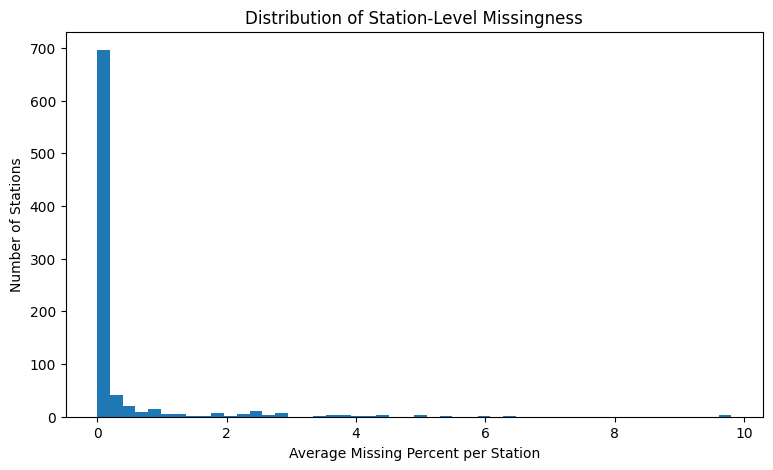

In [34]:
missing_by_station = (
    df.groupby("station_triplet")
      .apply(lambda x: x.isna().mean().mean() * 100)
      .reset_index(name="avg_missing_percent")
      .sort_values("avg_missing_percent", ascending=False)
)

display(missing_by_station.head(20))

plt.figure(figsize=(9, 5))
plt.hist(missing_by_station["avg_missing_percent"], bins=50)
plt.xlabel("Average Missing Percent per Station")
plt.ylabel("Number of Stations")
plt.title("Distribution of Station-Level Missingness")
plt.show()

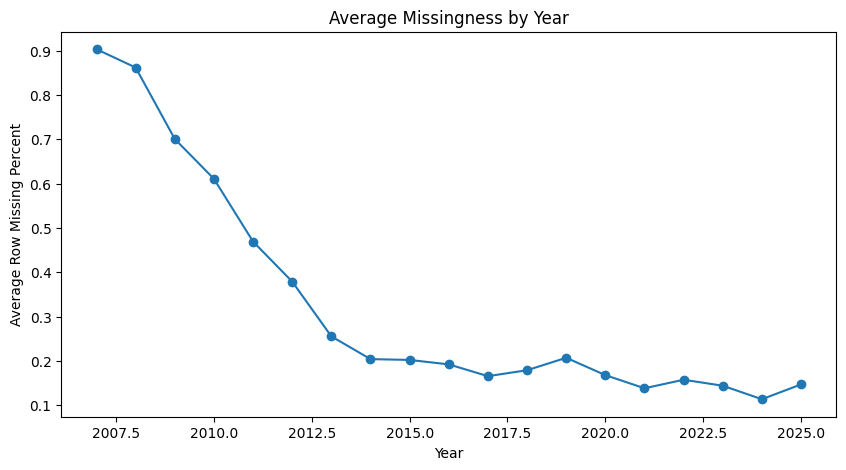

In [35]:
missing_by_year = (
    df.assign(row_missing_percent=df.isna().mean(axis=1) * 100)
      .groupby("year")["row_missing_percent"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(missing_by_year["year"], missing_by_year["row_missing_percent"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average Row Missing Percent")
plt.title("Average Missingness by Year")
plt.show()

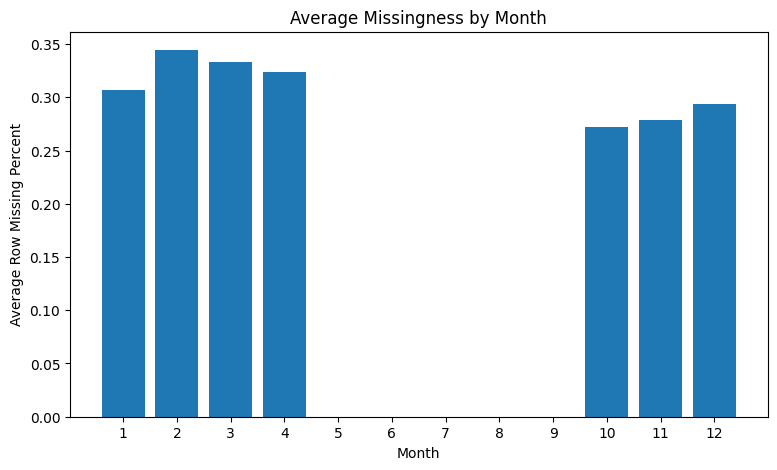

In [36]:
missing_by_month = (
    df.assign(row_missing_percent=df.isna().mean(axis=1) * 100)
      .groupby("month")["row_missing_percent"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))
plt.bar(missing_by_month["month"], missing_by_month["row_missing_percent"])
plt.xlabel("Month")
plt.ylabel("Average Row Missing Percent")
plt.title("Average Missingness by Month")
plt.xticks(range(1, 13))
plt.show()

## 5. Station Coverage Analysis

Each row corresponds to a station-month. Some stations may have long histories, while others may only have a few years of data. This section examines how much data is available per station and whether station coverage is balanced.

,station_triplet,name,stateCode,num_months
856,990:WA:SNTL,Beaver Pass,WA,131
0,1000:OR:SNTL,Annie Springs,OR,131
1,1001:AK:SNTL,Long Lake,AK,131
855,989:ID:SNTL,Moscow Mountain,ID,131
854,988:ID:SNTL,Hidden Lake,ID,131
4,1005:CO:SNTL,Ute Creek,CO,131
5,1006:NV:SNTL,Lewis Peak,NV,131
6,1008:MT:SNTL,Onion Park,MT,131
7,1009:MT:SNTL,Stringer Creek,MT,131
8,1010:OR:SNTL,Crazyman Flat,OR,131


,station_triplet,name,stateCode,num_months
216,2080:AK:SNTL,Tok,AK,28
682,785:AK:SNTL,McGrath,AK,28
52,1072:AK:SNTL,Kantishna,AK,28
214,1319:WA:SNTL,Decline Creek,WA,26
544,641:AK:SNTL,Frostbite Bottom,AK,25
136,1164:UT:SNTL,Wolf Creek Peak,UT,22
99,1126:WA:SNTL,Mt. Tebo,WA,22
187,1260:AK:SNTL,Chena Lakes,AK,21
65,1090:AK:SNTL,Upper Nome Creek,AK,21
203,1286:MT:SNTL,Slagamelt Lakes,MT,21


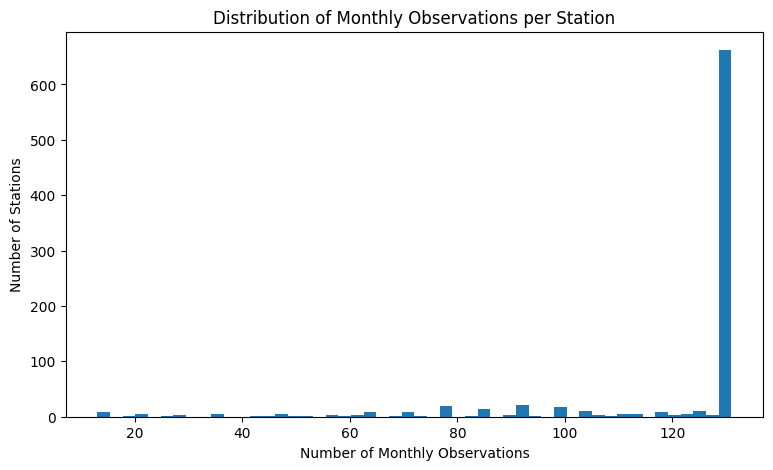

In [37]:
station_counts = (
    df.groupby(["station_triplet", "name", "stateCode"], dropna=False)
      .size()
      .reset_index(name="num_months")
      .sort_values("num_months", ascending=False)
)

display(station_counts.head(20))
display(station_counts.tail(20))

plt.figure(figsize=(9, 5))
plt.hist(station_counts["num_months"], bins=50)
plt.xlabel("Number of Monthly Observations")
plt.ylabel("Number of Stations")
plt.title("Distribution of Monthly Observations per Station")
plt.show()

,stateCode,num_rows,num_stations,avg_target_swe
10,UT,15113,135,7.774717
3,CO,14411,116,9.023003
5,MT,11731,92,10.693990
12,WY,11304,89,10.006254
4,ID,10710,85,11.388553
8,OR,10397,81,8.815110
11,WA,9105,76,18.069281
7,NV,4885,44,6.308966
0,AK,4722,54,7.306141
2,CA,4303,34,12.032233


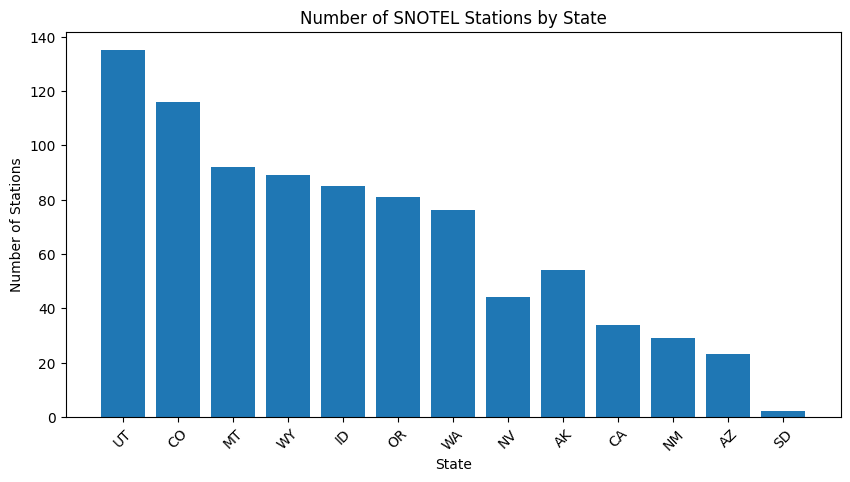

In [38]:
state_counts = (
    df.groupby("stateCode")
      .agg(
          num_rows=("station_triplet", "size"),
          num_stations=("station_triplet", "nunique"),
          avg_target_swe=(target, "mean")
      )
      .reset_index()
      .sort_values("num_rows", ascending=False)
)

display(state_counts)

plt.figure(figsize=(10, 5))
plt.bar(state_counts["stateCode"], state_counts["num_stations"])
plt.xlabel("State")
plt.ylabel("Number of Stations")
plt.title("Number of SNOTEL Stations by State")
plt.xticks(rotation=45)
plt.show()

## 6. Time Coverage Analysis

This section examines the number of observations available by year and month. Since the dataset spans multiple years and stations, this helps identify whether the data is balanced over time or concentrated in certain periods.

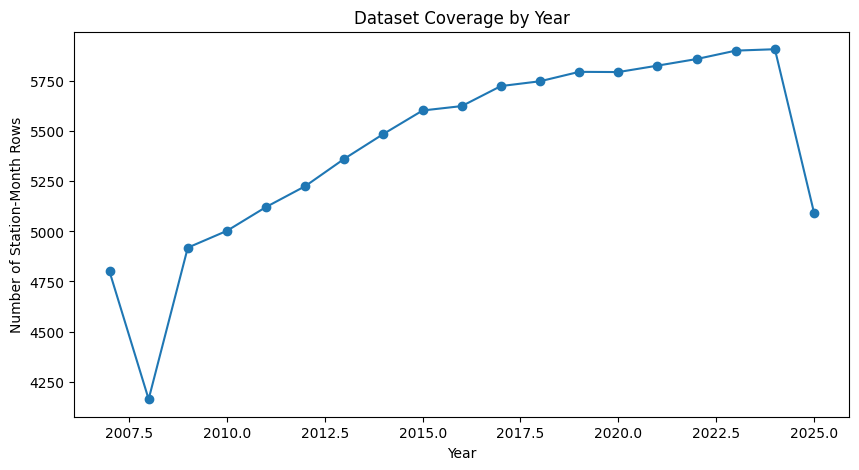

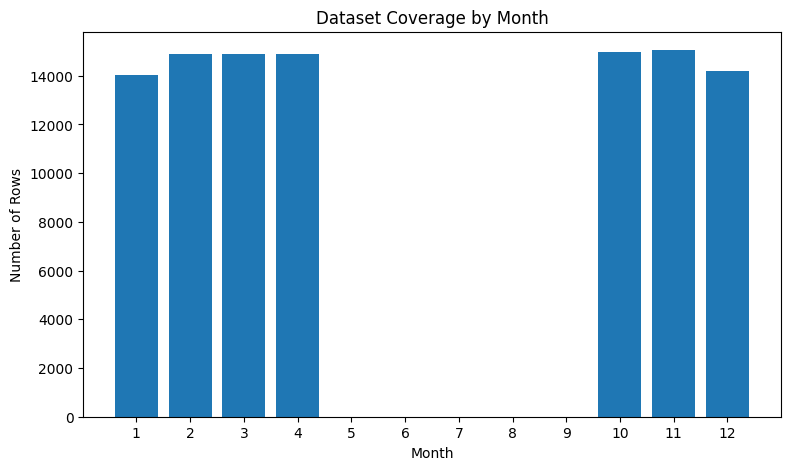

In [39]:
rows_by_year = df.groupby("year").size().reset_index(name="num_rows")

plt.figure(figsize=(10, 5))
plt.plot(rows_by_year["year"], rows_by_year["num_rows"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Station-Month Rows")
plt.title("Dataset Coverage by Year")
plt.show()

rows_by_month = df.groupby("month").size().reset_index(name="num_rows")

plt.figure(figsize=(9, 5))
plt.bar(rows_by_month["month"], rows_by_month["num_rows"])
plt.xlabel("Month")
plt.ylabel("Number of Rows")
plt.title("Dataset Coverage by Month")
plt.xticks(range(1, 13))
plt.show()

In [40]:
df.to_csv('../cleansed_data/cleansed_dataset.csv')